In [1]:
import numpy as np
import pandas as pd
import os
from os import path
import matplotlib.pyplot as plt

In [2]:
seeds = [6177, 2832, 7361, 2778, 5416, 9652, 125]
functions = [
    'benchmark_function_1',
    'benchmark_function_2'
]
algorithms = [
    'GD',
    'SGES',
    'ASGF',
    'ASHGF',
    'ASEBO'
]

C:\Users\manen\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:28: RuntimeWarning: Mean of empty slice
C:\Users\manen\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:29: RuntimeWarning: All-NaN axis encountered
C:\Users\manen\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:30: RuntimeWarning: All-NaN axis encountered


<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

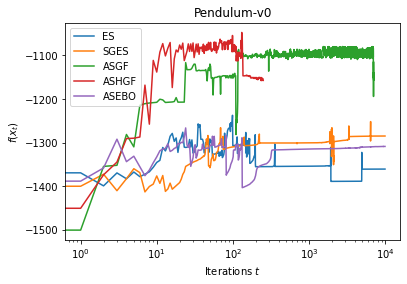

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

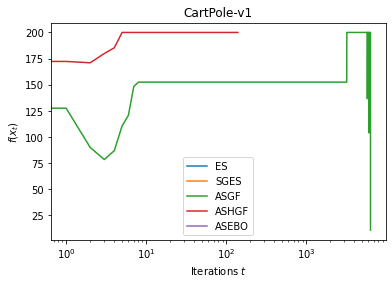

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

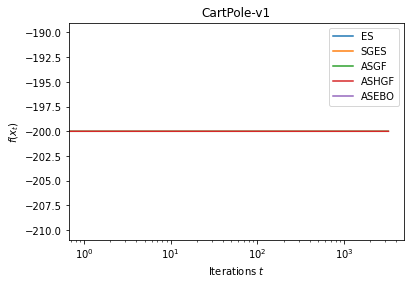

In [4]:
for function in functions:
    mean_descents = {}
    min_descents = {}
    max_descents = {}
    std_plus_descents = {}
    std_minus_descents = {}

    for algorithm in algorithms:
        plt.figure()

        descents = []
        longest_descent = 0
        min_descent = []
        max_descent = []
        mean_descent = []
        std_plus_descent = []
        std_minus_descent = []

        for seed in seeds:
            descent_path = os.path.join('results', 'RL', str(seed), function,
                                        algorithm, 'descent.csv')
            descent = pd.read_csv(descent_path)['descent'].tolist()
            descents.append(descent)

        min_num_it = int(np.max([len(best) for best in descents]))

        for i in range(min_num_it):
            values = [
                best[i] if i < len(best) else np.nan for best in descents
            ]
            mean_value = np.nanmean(values)
            min_value = np.nanmin(values)
            max_value = np.nanmax(values)
            std_value = np.nanstd(values)

            min_descent.append(min_value)
            max_descent.append(max_value)
            mean_descent.append(mean_value)
            std_plus_descent.append(mean_value + std_value)
            std_minus_descent.append(max([min_value, mean_value - std_value]))

        mean_descents[algorithm] = mean_descent
        min_descents[algorithm] = min_descent
        max_descents[algorithm] = max_descent
        std_plus_descents[algorithm] = std_plus_descent
        std_minus_descents[algorithm] = std_minus_descent

    for algorithm in algorithms:
        if algorithm == 'GD':
            plt.plot(mean_descents[algorithm], label='ES')
        else:
            plt.plot(mean_descents[algorithm], label=algorithm)
    plt.legend()
    plt.xscale('log')
    plt.legend()
    if function == 'benchmark_function_1':
        plt.title('Pendulum-v0')
    else:
        plt.title('CartPole-v1')
    plt.xlabel(r'Iterations $t$')
    plt.ylabel(r'$f(x_t)$')
    plt.savefig(os.path.join('results', 'RL_plots',
                             '{}_convergence_mean.png'.format(function)),
                dpi=600)
